# MEV

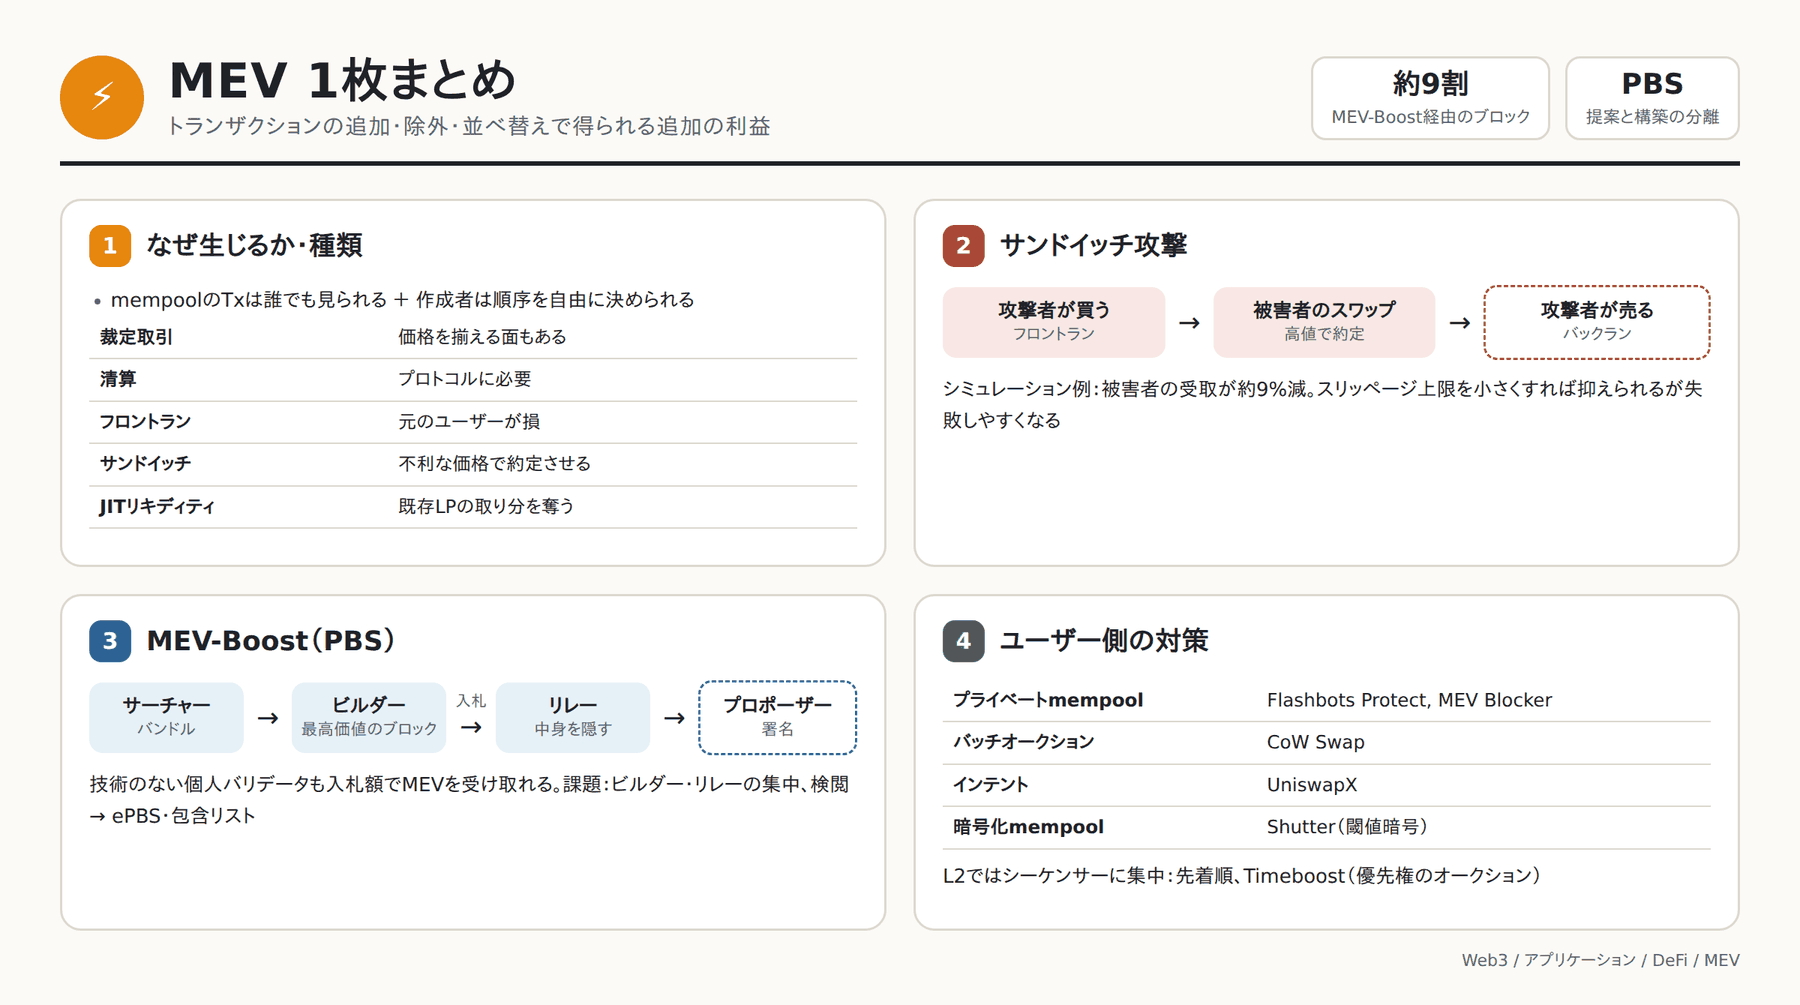

## MEVとは

**MEV（Maximal Extractable Value）** は、ブロックを作る際にトランザクションを **追加・除外・並べ替える** ことで得られる追加の利益。PoW時代はマイナーが得る利益という意味で Miner Extractable Value と呼ばれていた。

MEVが生じる理由は2つある。

- **mempoolのトランザクションは誰でも見られる**：誰が、どのDEXで、どのトークンをいくら交換しようとしているかが、ブロックに取り込まれる前に分かる
- **ブロック作成者はトランザクションの選択と順序を自由に決められる**：priority feeの高い順に並べるのが普通だが、義務ではない

さらに、ブロック作成者でなくても、高いgas代を付けたトランザクションを送れば、狙ったトランザクションの直前（または直後）に入れてもらえる可能性が高い。

## MEVの種類

| 種類 | 内容 | 社会的な影響 |
| --- | --- | --- |
| DEXの裁定取引 | DEX間・DEXとCEXの価格差を取る | 価格を揃える役割もあり、必ずしも有害ではない |
| 清算 | レンディングの清算を他より先に実行して清算ボーナスを得る | 清算自体はプロトコルに必要 |
| フロントランニング | 利益の出そうなトランザクションを見つけ、同じことを先に実行する | 元のユーザーが損をする |
| サンドイッチ攻撃 | 大口のスワップの直前に買い、直後に売る | スワップしたユーザーが不利な価格で約定する |
| JITリキディティ | 大口スワップの直前に集中流動性を提供し、直後に引き上げて手数料を取る | 既存のLPの取り分が減る |

### サンドイッチ攻撃

AMMでは、大口の買い注文が約定すると価格が上がる（→[AMM](./amm.ipynb)）。攻撃者はmempoolでそれを見つけ、

1. **フロントラン**：被害者のスワップの直前に同じトークンを買い、価格を吊り上げる
2. 被害者のスワップ：吊り上がった価格で約定する
3. **バックラン**：直後に売り抜けて利益を得る

被害者は、設定したスリッページ許容範囲の上限ぎりぎりの不利な価格で約定させられる。

In [1]:
def swap_x_for_y(x, y, dx, fee=0.003):
    dx_eff = dx * (1 - fee)
    dy = y * dx_eff / (x + dx_eff)
    return dy, x + dx, y - dy


def swap_y_for_x(x, y, dy, fee=0.003):
    dx, y2, x2 = swap_x_for_y(y, x, dy, fee)
    return dx, x2, y2


# ETH/USDC プール（X=USDC, Y=ETH）、ETH価格 = 2000 USDC
x0, y0 = 20_000_000.0, 10_000.0
victim_usdc = 500_000

# 攻撃がない場合
eth_fair, _, _ = swap_x_for_y(x0, y0, victim_usdc)

# サンドイッチ攻撃
attacker_usdc = 1_000_000
eth_atk, x1, y1 = swap_x_for_y(x0, y0, attacker_usdc)  # フロントラン
eth_victim, x2, y2 = swap_x_for_y(x1, y1, victim_usdc)  # 被害者
usdc_back, x3, y3 = swap_y_for_x(x2, y2, eth_atk)  # バックラン

print(f"被害者が受け取るETH: 攻撃なし {eth_fair:.2f} → 攻撃あり {eth_victim:.2f}（{(1 - eth_victim / eth_fair) * 100:.2f}% 減）")
print(f"攻撃者の利益: {usdc_back - attacker_usdc:,.0f} USDC（gas代・チップを除く）")

被害者が受け取るETH: 攻撃なし 243.19 → 攻撃あり 220.87（9.18% 減）
攻撃者の利益: 40,961 USDC（gas代・チップを除く）


スリッページ許容範囲を小さく設定すれば、価格が大きく動いたときにスワップが失敗するので被害を抑えられるが、通常の値動きでも失敗しやすくなる。

## PBSとMEV-Boost

### MEVの問題

MEVを放置すると、

- MEVを抽出する技術を持つ一部のバリデータだけが儲かり、ステークが集中する（中央集権化）
- 有利な順番を取るためのgas代の競り合い（Priority Gas Auction）でネットワークが混雑し、全体のgas代が上がる
- 失敗したトランザクションがブロック容量を浪費する

といった問題が起きる。MEVを完全になくすのは難しいため、**MEVの抽出を専門家に任せて競争させ、その利益をバリデータ全体に公平に行き渡らせる** という方向で対処しているのが現状である。

### Proposer-Builder Separation

**PBS（Proposer-Builder Separation）** は、ブロックの「中身を作る役（ビルダー）」と「ブロックを提案する役（プロポーザー＝バリデータ）」を分離する考え方。Flashbotsが開発した **MEV-Boost** は、これをプロトコル外のミドルウェアとして実現しており、Ethereumのブロックの約9割がMEV-Boost経由で作られている。

```mermaid
flowchart LR
    S["サーチャー<br/>MEVの機会を探し<br/>バンドルを作る"] -->|バンドル| B["ビルダー<br/>バンドルとTxを組み合わせて<br/>最も価値の高いブロックを作る"]
    B -->|"ブロック + 入札額"| R["リレー<br/>ブロックの中身を隠して<br/>ヘッダーと入札額を提示"]
    R -->|"ヘッダー + 入札額"| P["プロポーザー<br/>最高入札のヘッダーに署名"]
    P -->|署名| R
    R -->|"署名済みブロックを配信"| N["ネットワーク"]
```

| 役割 | 内容 |
| --- | --- |
| サーチャー | mempoolやチェーンの状態を監視して、裁定取引や清算などの機会を見つけ、自分のトランザクションを含む **バンドル**（順序が固定されたトランザクションの束）を作る。利益の一部をビルダーに支払う |
| ビルダー | 多数のバンドルと通常のトランザクションを組み合わせて、最も価値の高いブロック（Execution Payload）を作り、プロポーザーへの支払額（入札）を提示する |
| リレー | ビルダーとプロポーザーの間を仲介する。プロポーザーが中身を盗まないよう、署名前はヘッダーと入札額だけを見せる |
| プロポーザー | PoSで選ばれたバリデータ。最も高い入札のヘッダーに署名する |

プロポーザーは中身を自分で作らなくても、入札額という形でMEVの利益を受け取れる。そのため、MEVを抽出する技術を持たない個人のバリデータでも、大口のバリデータと同程度の報酬を得られる。

### 残る課題

- ビルダーやリレーが少数の事業者に集中している
- リレーは信頼された第三者である（プロトコルの外にある）
- 制裁対象のアドレスのトランザクションを除外するビルダーやリレーがあり、検閲耐性が問題になった

これらに対し、PBSをプロトコルに組み込む **ePBS（enshrined PBS, EIP-7732）** や、プロポーザーが含めるべきトランザクションのリストを指定できる **包含リスト（inclusion lists, FOCIL）** が検討されている。

## ユーザー側のMEV対策

| 対策 | 仕組み | 例 |
| --- | --- | --- |
| プライベートmempool | トランザクションを公開mempoolに流さず、ビルダーに直接送る | Flashbots Protect, MEV Blocker |
| バッチオークション | 一定期間の注文をまとめて同じ価格で約定させ、順序による有利不利をなくす | CoW Swap |
| インテント | 約定条件だけに署名し、ソルバーが競争して約定させる。MEVの一部をユーザーに還元する | UniswapX, CoW Swap |
| 暗号化mempool | トランザクションを暗号化し、順序が確定してから復号する。閾値暗号で特定の誰かだけが復号できないようにする | Shutter Network |
| スリッページ制限 | 許容する価格の悪化幅を小さくする | （各DEXの設定） |

L2では、シーケンサーが単独でトランザクションを並べるため、MEVはシーケンサーの手に集中する。先着順（FCFS）での処理や、Arbitrumの Timeboost（優先順位をオークションで販売する）など、L2ごとに異なる方針が取られている。

## 参考文献

- Daian, P. et al. (2020). [Flash Boys 2.0: Frontrunning in Decentralized Exchanges, Miner Extractable Value, and Consensus Instability](https://arxiv.org/abs/1904.05234). IEEE S&P.
- [Flashbots Docs](https://docs.flashbots.net/)
- [Maximal extractable value (MEV) | ethereum.org](https://ethereum.org/developers/docs/mev/)
- [mevboost.pics](https://mevboost.pics/)